--- GENERATING WEATHER DATASET ---
--- TASK 30: Line Plots for Time Series ---


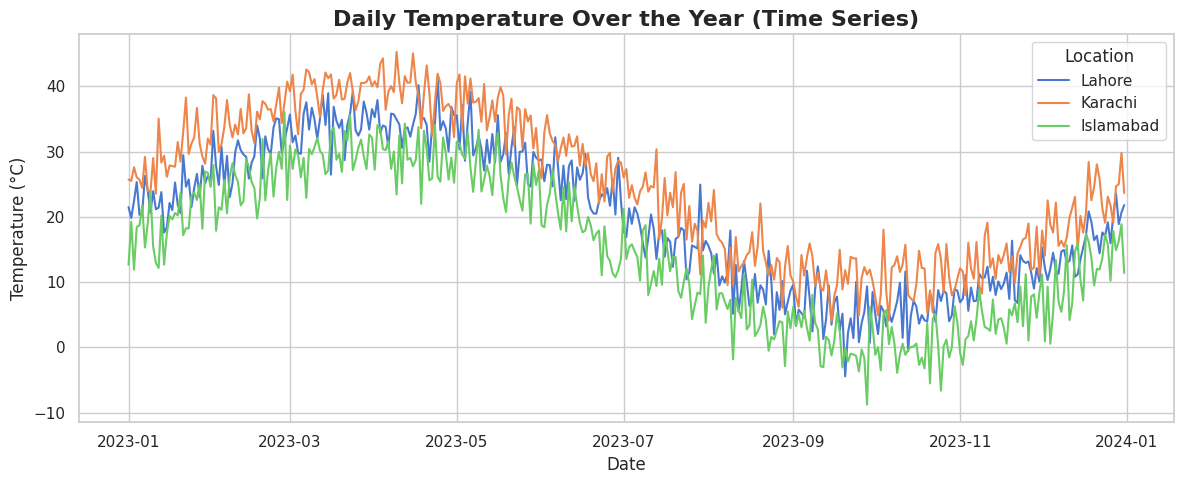


--- TASK 36: Create Subplots & Multi-panel Figures ---
--- TASK 31: Bar Charts & Histograms ---
--- TASK 32: Scatter Plots ---


/tmp/ipykernel_1730/1138937185.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="City", y="Rainfall (mm)", ax=axes[0], estimator=np.sum, palette="Blues_d")


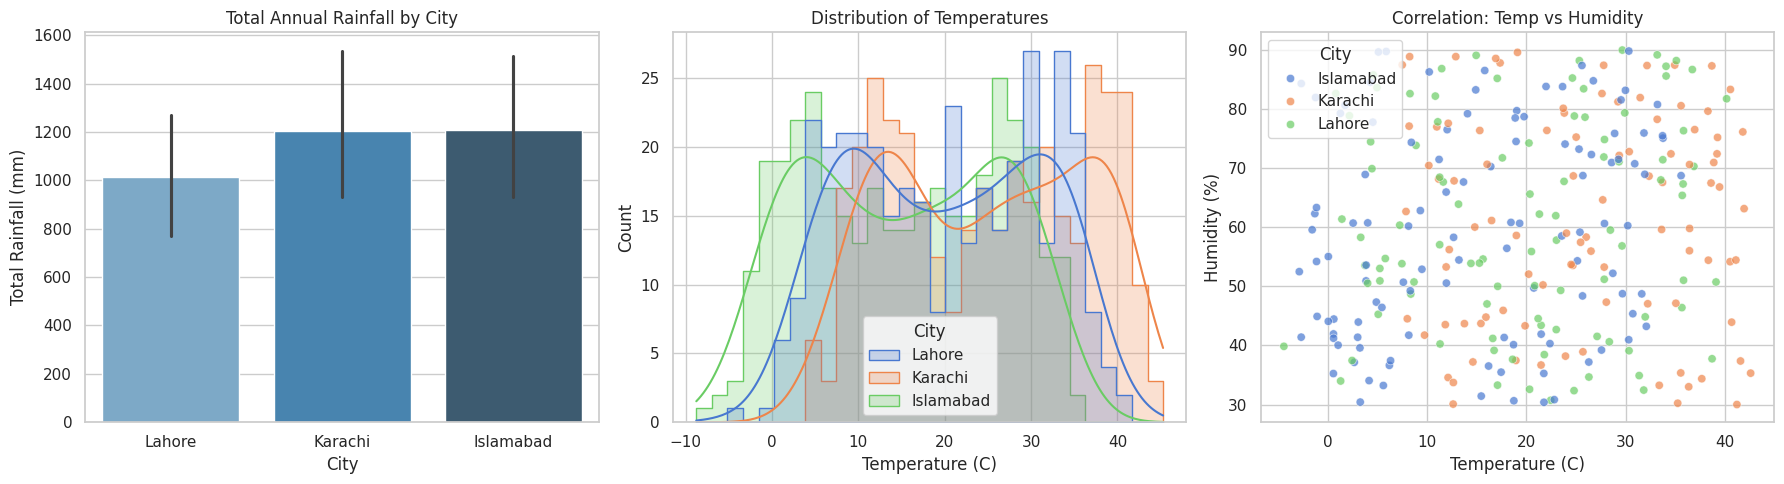


--- TASK 33: Box Plots and Violin Plots ---


/tmp/ipykernel_1730/1138937185.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="City", y="Wind Speed (km/h)", palette="Set2", ax=axes[0])
/tmp/ipykernel_1730/1138937185.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="City", y="Temperature (C)", palette="Set3", inner="quartile", ax=axes[1])


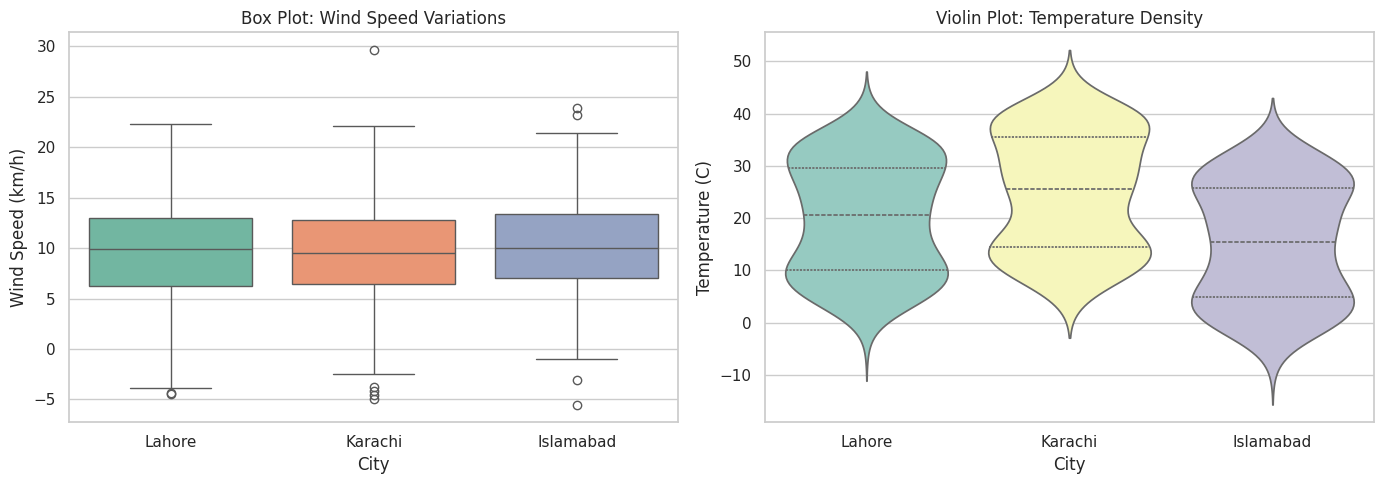


--- TASK 34: Heatmaps for Correlation Matrices ---


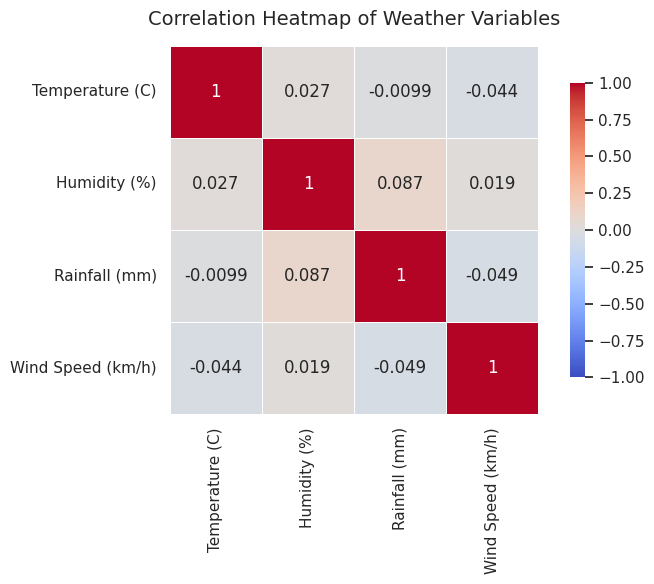


🎉 PORTFOLIO COMPLETE! 🎉


In [1]:
# Portfolio: Practical Tasks 5 - Data Visualization Portfolio

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set a beautiful default theme for Seaborn
sns.set_theme(style="whitegrid", palette="muted")

print("--- GENERATING WEATHER DATASET ---")
np.random.seed(42)
dates = pd.date_range(start="2023-01-01", end="2023-12-31", freq="D")
cities = ["Lahore", "Karachi", "Islamabad"]

data = []
for city in cities:
    # Simulating realistic weather patterns
    base_temp = 25 if city == "Karachi" else (20 if city == "Lahore" else 15)
    temp = base_temp + np.sin(np.arange(365) * (2 * np.pi / 365)) * 15 + np.random.normal(0, 3, 365)
    humidity = np.random.uniform(30, 90, 365)
    rainfall = np.where(np.random.rand(365) > 0.7, np.random.exponential(10, 365), 0)
    wind_speed = np.random.normal(10, 5, 365)

    city_df = pd.DataFrame({
        "Date": dates, "City": city, "Temperature (C)": temp,
        "Humidity (%)": humidity, "Rainfall (mm)": rainfall, "Wind Speed (km/h)": wind_speed
    })
    data.append(city_df)

df = pd.concat(data, ignore_index=True)
df['Month'] = df['Date'].dt.month_name().str[:3]

# Task 35: Customizations (Colors, Labels, Titles) are applied to ALL plots below!

print("--- TASK 30: Line Plots for Time Series ---")
plt.figure(figsize=(12, 5))
sns.lineplot(data=df, x="Date", y="Temperature (C)", hue="City", linewidth=1.5)
plt.title("Daily Temperature Over the Year (Time Series)", fontsize=16, fontweight='bold')
plt.xlabel("Date", fontsize=12)
plt.ylabel("Temperature (°C)", fontsize=12)
plt.legend(title="Location")
plt.tight_layout()
plt.show()

print("\n--- TASK 36: Create Subplots & Multi-panel Figures ---")
print("--- TASK 31: Bar Charts & Histograms ---")
print("--- TASK 32: Scatter Plots ---")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Bar Chart (Average Rainfall per City)
sns.barplot(data=df, x="City", y="Rainfall (mm)", ax=axes[0], estimator=np.sum, palette="Blues_d")
axes[0].set_title("Total Annual Rainfall by City")
axes[0].set_ylabel("Total Rainfall (mm)")

# 2. Histogram (Temperature Distribution)
sns.histplot(data=df, x="Temperature (C)", hue="City", bins=30, kde=True, ax=axes[1], element="step")
axes[1].set_title("Distribution of Temperatures")

# 3. Scatter Plot (Humidity vs. Temperature)
sns.scatterplot(data=df.sample(300), x="Temperature (C)", y="Humidity (%)", hue="City", alpha=0.7, ax=axes[2])
axes[2].set_title("Correlation: Temp vs Humidity")

plt.tight_layout()
plt.show()

print("\n--- TASK 33: Box Plots and Violin Plots ---")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box Plot
sns.boxplot(data=df, x="City", y="Wind Speed (km/h)", palette="Set2", ax=axes[0])
axes[0].set_title("Box Plot: Wind Speed Variations")

# Violin Plot
sns.violinplot(data=df, x="City", y="Temperature (C)", palette="Set3", inner="quartile", ax=axes[1])
axes[1].set_title("Violin Plot: Temperature Density")

plt.tight_layout()
plt.show()

print("\n--- TASK 34: Heatmaps for Correlation Matrices ---")
plt.figure(figsize=(8, 6))
# Calculate correlation only on numeric columns
corr_matrix = df[["Temperature (C)", "Humidity (%)", "Rainfall (mm)", "Wind Speed (km/h)"]].corr()

# Create Heatmap
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .8})
plt.title("Correlation Heatmap of Weather Variables", fontsize=14, pad=15)
plt.tight_layout()
plt.show()